## Importações e Carregamento de Dados

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datetime import datetime
import os
from dotenv import load_dotenv
load_dotenv()

# Configuração para visualizações
plt.style.use('ggplot')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

# Carregar o arquivo de resultados de avaliação
memory = True
database = os.getenv("EXPERIMENT_NAME")
experiment_memory = "memory" if memory else "agent_without_memory"
json_file = f'user_agent/gpt-4o-{experiment_memory}-{database}-eval.json'
# json_file = f'user_agent/gpt-4o-memory-mondial-eval_first.json'
with open(json_file, 'r', encoding='utf-8') as f:
    results = json.load(f)

# Mostrar a estrutura básica
print(f"Total de experimentos: {len(results)}")
print(f"Experimento de exemplo: {results[0]['experiment_id']}")
print(f"Configuração de experimento: {results[0]['experiment_config']}")

Total de experimentos: 49
Experimento de exemplo: 1
Configuração de experimento: {'max_retries': 2, 'model_version': 'default', 'timestamp': '2026-02-13T17:51:51.424412', 'experiment_type': 'standard'}


Total de turnos analisados: 496
Porcentagem de alinhamento (alignment=True): 98.99%
Porcentagem de correção (correctness=True ou sql=''): 61.29%


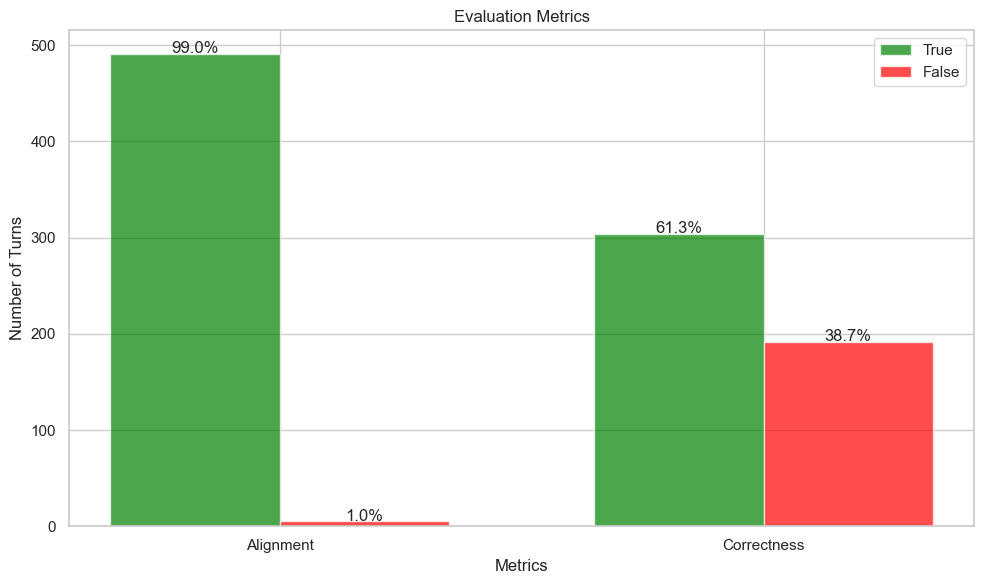

In [2]:
# Célula 1: Análise de alinhamento e correção de consultas SQL

# Extrair todos os turnos de todos os experimentos
all_turns = []
for experiment in results:
    for interaction in experiment['experiment_eval']:
        for turn in interaction['turns']:
            if 'evaluation' in turn:
                all_turns.append(turn['evaluation'])

# Calcular porcentagens
total_turns = len(all_turns)

# Alinhamento permanece igual
alignment_true = sum(1 for turn in all_turns if turn.get('alignment') == True or
                     (turn.get('correctness') == True and turn.get('generated_sql', "") != ""))

# Correctness é verdadeiro se correctness=True OU generated_sql=""
correctness_true = sum(1 for turn in all_turns if 
                      turn.get('correctness') == True and 
                      (turn.get('generated_sql', "") != ""))

alignment_percent = (alignment_true / total_turns) * 100
correctness_percent = (correctness_true / total_turns) * 100

print(f"Total de turnos analisados: {total_turns}")
print(f"Porcentagem de alinhamento (alignment=True): {alignment_percent:.2f}%")
print(f"Porcentagem de correção (correctness=True ou sql=''): {correctness_percent:.2f}%")

# Criando o histograma
metrics = ['Alignment', 'Correctness']
true_values = [alignment_true, correctness_true]
false_values = [total_turns - alignment_true, total_turns - correctness_true]

fig, ax = plt.subplots(figsize=(10, 6))
width = 0.35
x = np.arange(len(metrics))

ax.bar(x - width/2, true_values, width, label='True', color='green', alpha=0.7)
ax.bar(x + width/2, false_values, width, label='False', color='red', alpha=0.7)

ax.set_title('Evaluation Metrics')
ax.set_ylabel('Number of Turns')
ax.set_xlabel('Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Adicionar porcentagens nos topos das barras
for i, v in enumerate(true_values):
    ax.text(i - width/2, v + 0.5, f"{(v/total_turns)*100:.1f}%", ha='center')
    
for i, v in enumerate(false_values):
    ax.text(i + width/2, v + 0.5, f"{(v/total_turns)*100:.1f}%", ha='center')

plt.tight_layout()
plt.show()

Total de diálogos: 49
Diálogos bem-sucedidos: 49
Taxa de sucesso: 100.00%


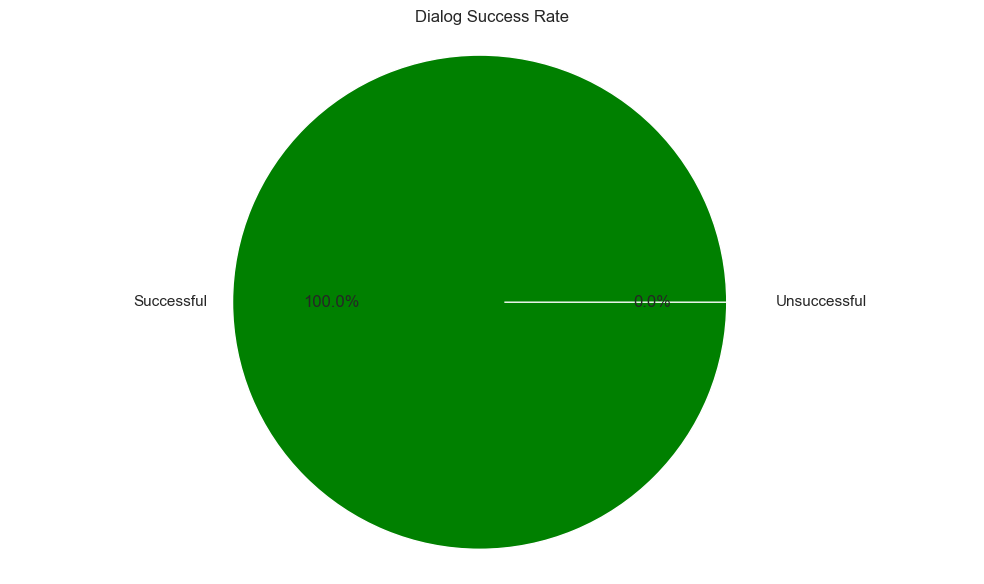

In [3]:
# Célula 2: Análise de diálogos bem-sucedidos

# Definir um diálogo bem-sucedido como aquele onde o último turno de cada interação 
# tem alignment=True ou correctness=True
successful_dialogs = 0
total_dialogs = len(results)

for experiment in results:
    experiment_success = True
    
    for interaction in experiment['experiment_eval']:
        # Verificar se existe pelo menos um turno
        if not interaction['turns']:
            experiment_success = False
            continue
            
        # Pegar o último turno da interação
        last_turn = interaction['turns'][-1]
        
        # Verificar se o último turno tem alignment=True ou correctness=True
        if 'evaluation' not in last_turn or (last_turn['evaluation'].get('alignment') != True and 
                                             last_turn['evaluation'].get('correctness') != True):
            experiment_success = False
    
    if experiment_success:
        successful_dialogs += 1

success_rate = (successful_dialogs / total_dialogs) * 100

print(f"Total de diálogos: {total_dialogs}")
print(f"Diálogos bem-sucedidos: {successful_dialogs}")
print(f"Taxa de sucesso: {success_rate:.2f}%")

# Visualização
labels = ['Successful', 'Unsuccessful']
sizes = [successful_dialogs, total_dialogs - successful_dialogs]
colors = ['green', 'red']
explode = (0.1, 0)

plt.figure(figsize=(10, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%')
plt.axis('equal')
plt.title('Dialog Success Rate')
plt.tight_layout()
plt.show()

Total de diálogos: 49
Diálogos bem-sucedidos com 1 turno por interação: 43
Taxa de sucesso (1 turno/interação): 87.76%


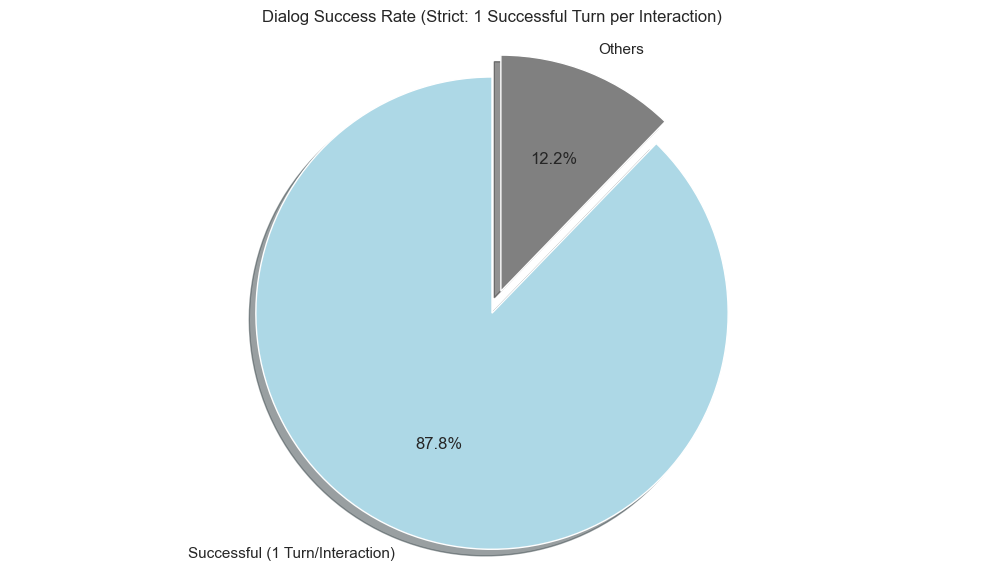

In [4]:
# Célula 4: Análise de diálogos bem-sucedidos em um único turno por interação

# Contar diálogos onde TODAS as interações foram resolvidas com sucesso em EXATAMENTE UM turno
single_turn_successful_dialogs = 0
total_dialogs = len(results)

for experiment in results:
    experiment_single_turn_success = True
    
    # Verifica se há interações no experimento
    if not experiment['experiment_eval']:
        experiment_single_turn_success = False
        continue

    for interaction in experiment['experiment_eval']:
        # Verifica se a interação teve exatamente UM turno
        if len(interaction['turns']) != 1:
            experiment_single_turn_success = False
            break # Se qualquer interação tiver mais de 1 turno, o diálogo falha neste critério

        # Pega o único turno
        single_turn = interaction['turns'][0]

        # Verifica se o único turno foi bem-sucedido (alignment ou correctness True)
        if 'evaluation' not in single_turn or \
           (single_turn['evaluation'].get('alignment') != True and single_turn['evaluation'].get('correctness') != True):
            experiment_single_turn_success = False
            break # Se o único turno não foi bem-sucedido, o diálogo falha

    if experiment_single_turn_success:
        single_turn_successful_dialogs += 1

single_turn_success_rate = (single_turn_successful_dialogs / total_dialogs) * 100

print(f"Total de diálogos: {total_dialogs}")
print(f"Diálogos bem-sucedidos com 1 turno por interação: {single_turn_successful_dialogs}")
print(f"Taxa de sucesso (1 turno/interação): {single_turn_success_rate:.2f}%")

# Visualização
labels = ['Successful (1 Turn/Interaction)', 'Others']
sizes = [single_turn_successful_dialogs, total_dialogs - single_turn_successful_dialogs]
colors = ['lightblue', 'grey']
explode = (0.1, 0)

plt.figure(figsize=(10, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
plt.axis('equal')
plt.title('Dialog Success Rate (Strict: 1 Successful Turn per Interaction)')
plt.tight_layout()
plt.show()

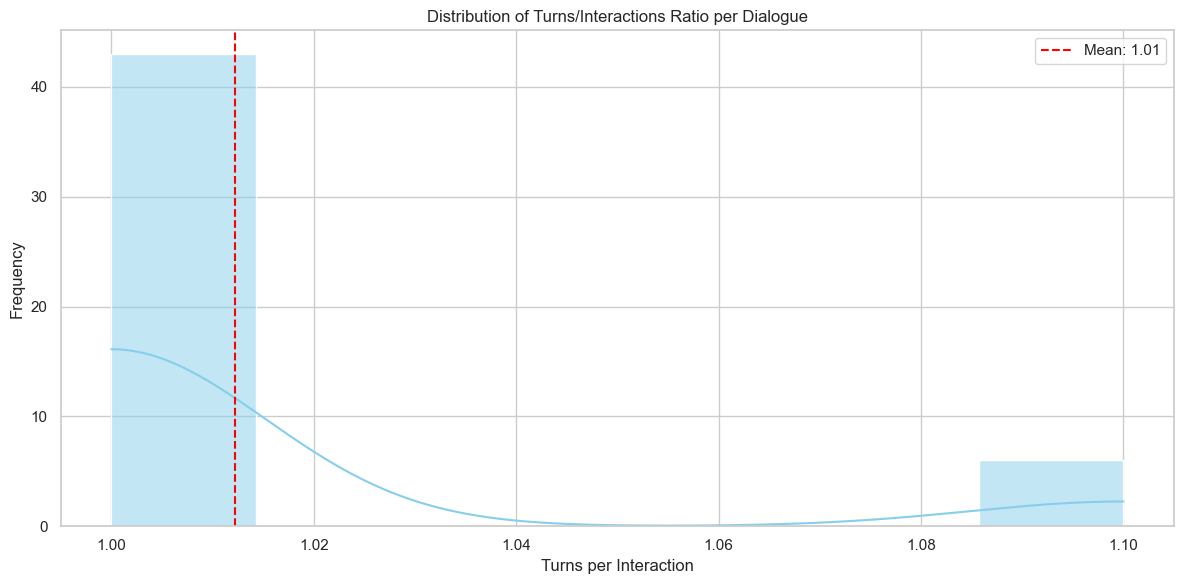

Estatísticas da razão turnos/interações:
count    49.000000
mean      1.012245
std       0.033120
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       1.100000
Name: ratio, dtype: float64

Média de turnos por interação: 1.01
Diálogo com maior razão: Experimento 1 (Razão: 1.10)


In [5]:
# Célula 3: Análise da razão turnos/interações

# Calcular a razão entre número de turnos e número de interações para cada diálogo
dialog_ratios = []

for experiment in results:
    total_turns = 0
    total_interactions = len(experiment['experiment_eval'])
    
    if total_interactions == 0:
        continue
    
    for interaction in experiment['experiment_eval']:
        total_turns += len(interaction['turns'])
    
    ratio = total_turns / total_interactions
    dialog_ratios.append({
        'experiment_id': experiment['experiment_id'],
        'ratio': ratio,
        'turns': total_turns,
        'interactions': total_interactions
    })

# Converter para DataFrame para facilitar a visualização
ratio_df = pd.DataFrame(dialog_ratios)
average_ratio = ratio_df['ratio'].mean()

# Visualização da distribuição
plt.figure(figsize=(12, 6))
sns.histplot(ratio_df['ratio'], kde=True, color='skyblue')
plt.axvline(x=average_ratio, color='red', linestyle='--', label=f'Mean: {average_ratio:.2f}')
plt.title('Distribution of Turns/Interactions Ratio per Dialogue')
plt.xlabel('Turns per Interaction')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# Estatísticas descritivas
print(f"Estatísticas da razão turnos/interações:")
print(ratio_df['ratio'].describe())
print(f"\nMédia de turnos por interação: {average_ratio:.2f}")
print(f"Diálogo com maior razão: Experimento {ratio_df.loc[ratio_df['ratio'].idxmax()]['experiment_id']} "
      f"(Razão: {ratio_df['ratio'].max():.2f})")

## Processamento dos Dados em DataFrame

In [6]:
# Função para aplainar os dados hierárquicos do JSON em um DataFrame
def flatten_evaluation_data(results):
    rows = []
    
    for experiment in results:
        experiment_id = experiment.get("experiment_id")
        experiment_config = experiment.get("experiment_config", {})
        model_version = experiment_config.get("model_version", "desconhecido")
        max_retries = experiment_config.get("max_retries", 0)
        experiment_type = experiment_config.get("experiment_type", "standard")
        
        for interaction in experiment.get("experiment_eval", []):
            interaction_id = interaction.get("interaction_id")
            original_intent = interaction.get("original_intent", "")
            total_retries_needed = interaction.get("total_retries_needed", 0)
            success_without_retry = interaction.get("success_without_retry", True)
            execution_time = interaction.get("execution_time", 0)
            
            for turn in interaction.get("turns", []):
                turn_id = turn.get("turn_id")
                user_query = turn.get("user_query", "")
                agent_reply = turn.get("agent_reply", "")
                evaluation = turn.get("evaluation", {})
                
                # Extrair métricas de avaliação
                text_to_sql_input = evaluation.get("text_to_sql_input", "")
                user_intention = evaluation.get("user_intention", "")
                recall = evaluation.get("recall", None)
                alignment = evaluation.get("alignment", None)
                correctness = evaluation.get("correctness", None)
                is_retry = evaluation.get("is_retry", False)
                retry_count = evaluation.get("retry_count", 0)
                retry_reason = evaluation.get("retry_reason", None)
                execution_time_turn = evaluation.get("execution_time", 0)
                query_complexity = evaluation.get("query_complexity", "unknown")
                
                rows.append({
                    # Metadados de experimento
                    "experiment_id": experiment_id,
                    "model_version": model_version,
                    "max_retries": max_retries,
                    "experiment_type": experiment_type,
                    
                    # Metadados de interação
                    "interaction_id": interaction_id,
                    "original_intent": original_intent,
                    "total_retries_needed": total_retries_needed,
                    "success_without_retry": success_without_retry,
                    "interaction_execution_time": execution_time,
                    
                    # Dados do turno
                    "turn_id": turn_id,
                    "user_query": user_query,
                    "agent_reply": agent_reply,
                    
                    # Métricas de avaliação
                    "text_to_sql_input": text_to_sql_input,
                    "user_intention": user_intention,
                    "recall": recall,
                    "alignment": alignment,
                    "correctness": correctness,
                    "is_retry": is_retry,
                    "retry_count": retry_count,
                    "retry_reason": retry_reason,
                    "turn_execution_time": execution_time_turn,
                    "query_complexity": query_complexity
                })
    
    return pd.DataFrame(rows)

# Criar o DataFrame
df = flatten_evaluation_data(results)

# Mostrar as primeiras linhas
print("Forma do DataFrame:", df.shape)
df.head()

Forma do DataFrame: (496, 22)


,experiment_id,model_version,max_retries,experiment_type,interaction_id,original_intent,total_retries_needed,success_without_retry,interaction_execution_time,turn_id,...,text_to_sql_input,user_intention,recall,alignment,correctness,is_retry,retry_count,retry_reason,turn_execution_time,query_complexity
0,1,default,2,standard,1,Find the latitude and longitude of all airports.,0,True,0.0,1,...,Provide the latitude and longitude of all airp...,Find the latitude and longitude of all airports.,0.0,True,True,False,0,None,29.645125,simples
1,1,default,2,standard,2,Find cities with airports located in the same ...,0,True,0.0,1,...,List cities that have airports and are in the ...,Find cities with airports located in the same ...,0.0,True,False,False,0,None,20.390757,simples
2,1,default,2,standard,3,Retrieve the elevation levels of airports.,0,True,0.0,1,...,Provide the elevation levels of all airports a...,Retrieve the elevation levels of airports.,0.0,True,True,False,0,None,18.111263,simples
3,1,default,2,standard,4,Find provinces where cities and airports share...,0,True,0.0,1,...,List provinces where airports and cities have ...,Find provinces where cities and airports share...,0.0,True,False,False,0,None,14.622228,simples
4,1,default,2,standard,5,Identify islands with airports and matching pr...,0,True,0.0,1,...,Find islands that have airports and matching p...,Identify islands with airports and matching pr...,0.0,True,False,False,0,None,17.477917,simples


## Métricas Gerais de Desempenho

=== Estatísticas Gerais ===
Total de interações: 10
Total de turnos: 496
Média de turnos por interação: 49.60

=== Taxas de Sucesso ===
Taxa de alinhamento (alignment): 98.79%
Taxa de correção SQL (correctness): 61.29%
Taxa de sucesso completo (alignment + correctness): 61.09%
Recall médio na identificação de tabelas: 1.92%


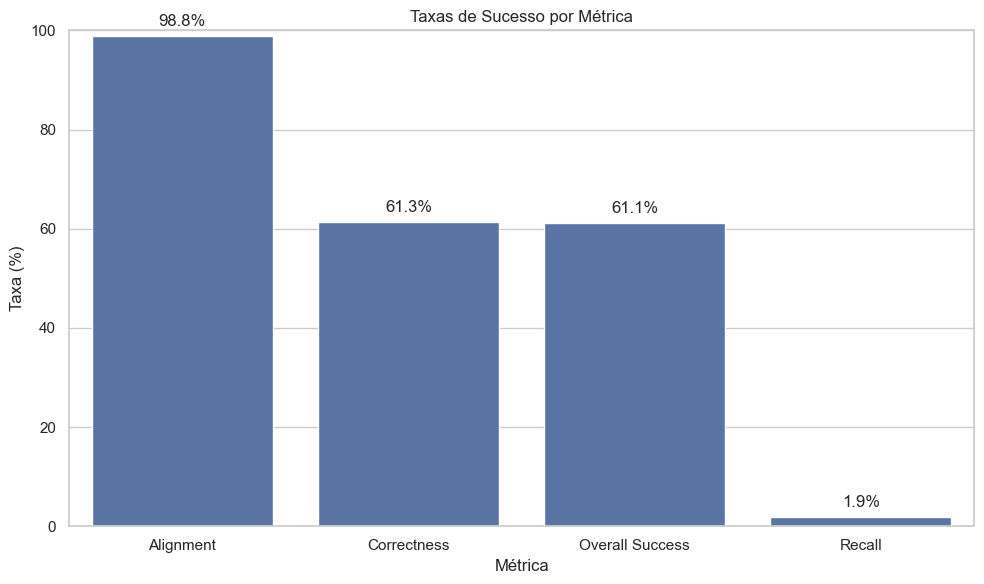

In [7]:
# Filtrar apenas os turnos com avaliação completa (sem valores nulos em métricas principais)
df_complete = df.dropna(subset=['recall', 'alignment', 'correctness'])

# 1. Estatísticas Gerais
print("=== Estatísticas Gerais ===")
total_interactions = df_complete['interaction_id'].nunique()
total_turns = len(df_complete)
print(f"Total de interações: {total_interactions}")
print(f"Total de turnos: {total_turns}")
print(f"Média de turnos por interação: {total_turns/total_interactions:.2f}")

# 2. Taxas de Sucesso
print("\n=== Taxas de Sucesso ===")
alignment_rate = df_complete['alignment'].mean() * 100
correctness_rate = df_complete['correctness'].mean() * 100
overall_success = (df_complete['alignment'] & df_complete['correctness']).mean() * 100
recall_mean = df_complete['recall'].mean() * 100

print(f"Taxa de alinhamento (alignment): {alignment_rate:.2f}%")
print(f"Taxa de correção SQL (correctness): {correctness_rate:.2f}%")
print(f"Taxa de sucesso completo (alignment + correctness): {overall_success:.2f}%")
print(f"Recall médio na identificação de tabelas: {recall_mean:.2f}%")

# 3. Gráfico de taxas de sucesso
success_metrics = pd.DataFrame({
    'Métrica': ['Alignment', 'Correctness', 'Overall Success', 'Recall'],
    'Taxa (%)': [alignment_rate, correctness_rate, overall_success, recall_mean]
})

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Métrica', y='Taxa (%)', data=success_metrics)
plt.title('Taxas de Sucesso por Métrica')
plt.ylim(0, 100)

# Adicionar valores nas barras
for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'bottom', 
                xytext = (0, 5), textcoords = 'offset points')

plt.tight_layout()
plt.show()

## Análise de Retentativas (Retries)

=== Estatísticas de Retentativas ===
Interações que necessitaram de retentativa: 4 (40.00%)

Distribuição de retentativas por interação:
0 retentativa(s): 6 interações (60.00%)
2 retentativa(s): 4 interações (40.00%)

=== Motivos de Retentativa ===
alignment_and_correctness_failure: 4 ocorrências (66.67%)
alignment_failure: 1 ocorrências (16.67%)
feedback_needed: 1 ocorrências (16.67%)


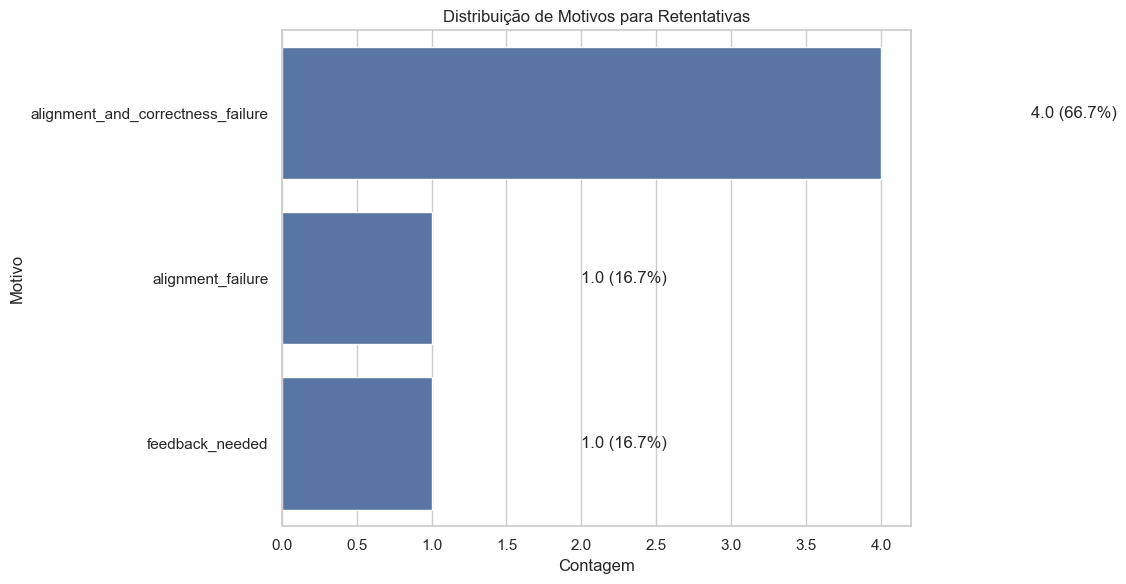

/var/folders/vx/6n609lh96v91_0jh1hzlvn5w0000gn/T/ipykernel_8201/196291631.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  success_rates = success_by_retry.groupby('retry_group')['correctness'].mean() * 100


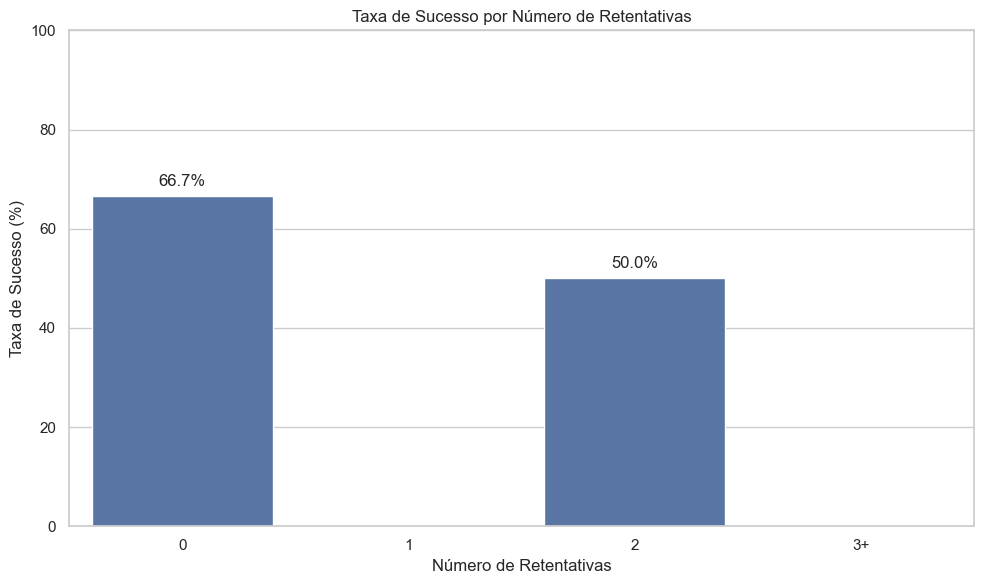

In [8]:
# 1. Estatísticas de Retentativas
print("=== Estatísticas de Retentativas ===")
interactions_with_retry = df.loc[df['total_retries_needed'] > 0, 'interaction_id'].nunique()
retry_rate = interactions_with_retry / total_interactions * 100
print(f"Interações que necessitaram de retentativa: {interactions_with_retry} ({retry_rate:.2f}%)")

# Distribuição do número de retentativas por interação
retry_counts = df.groupby('interaction_id')['total_retries_needed'].max().value_counts().sort_index()
print("\nDistribuição de retentativas por interação:")
for retries, count in retry_counts.items():
    print(f"{retries} retentativa(s): {count} interações ({count/total_interactions*100:.2f}%)")

# 2. Análise por Motivo de Retentativa
# Filtrar apenas turnos que são retentativas
retry_turns = df[df['is_retry'] == True].copy()
retry_reasons = retry_turns['retry_reason'].value_counts()

print("\n=== Motivos de Retentativa ===")
for reason, count in retry_reasons.items():
    print(f"{reason}: {count} ocorrências ({count/len(retry_turns)*100:.2f}%)")

# 3. Gráfico de motivos de retentativa
plt.figure(figsize=(12, 6))
ax = sns.countplot(y='retry_reason', data=retry_turns, order=retry_reasons.index)
plt.title('Distribuição de Motivos para Retentativas')
plt.xlabel('Contagem')
plt.ylabel('Motivo')

# Adicionar valores nas barras
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 1, p.get_y() + p.get_height()/2, f'{width} ({width/len(retry_turns)*100:.1f}%)', 
             ha='left', va='center')

plt.tight_layout()
plt.show()

# 4. Impacto das retentativas no sucesso final
success_by_retry = df.groupby('interaction_id').agg({
    'total_retries_needed': 'max',
    'correctness': lambda x: x.iloc[-1] if not x.empty else None  # Pega o último valor
}).reset_index()

success_by_retry['retry_group'] = pd.cut(success_by_retry['total_retries_needed'], 
                                         bins=[-1, 0, 1, 2, float('inf')],
                                         labels=['0', '1', '2', '3+'])

success_rates = success_by_retry.groupby('retry_group')['correctness'].mean() * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=success_rates.index, y=success_rates.values)
plt.title('Taxa de Sucesso por Número de Retentativas')
plt.xlabel('Número de Retentativas')
plt.ylabel('Taxa de Sucesso (%)')
plt.ylim(0, 100)

# Adicionar valores nas barras
for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'bottom', 
                xytext = (0, 5), textcoords = 'offset points')

plt.tight_layout()
plt.show()

## Análise de Complexidade das Queries

=== Distribuição de Complexidade das Queries ===
simples: 277 queries (55.85%)
média: 189 queries (38.10%)
complexa: 30 queries (6.05%)


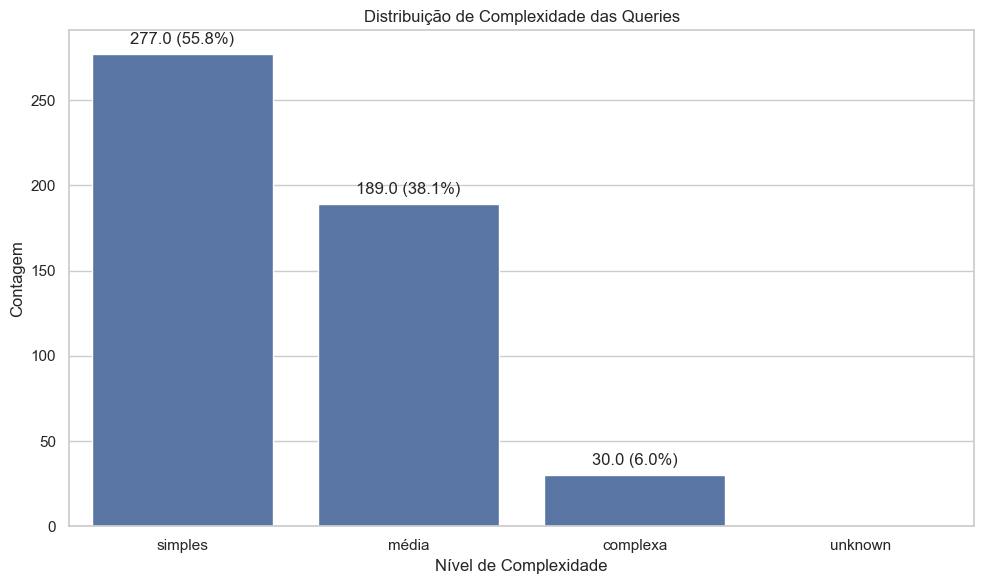


=== Taxa de Sucesso por Complexidade ===
                   alignment  correctness    recall
query_complexity                                   
complexa          100.000000    63.333333  0.000000
média              98.941799    56.613757  2.380952
simples            98.555957    64.259928  1.805054


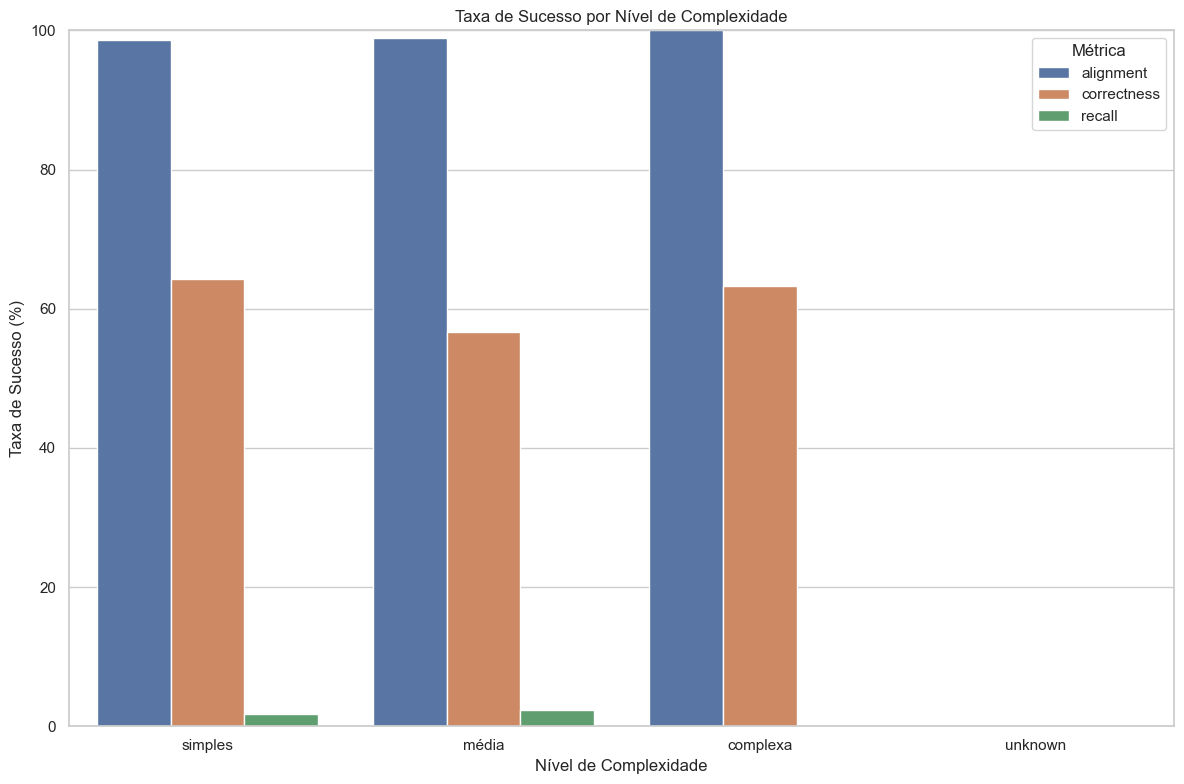


=== Média de Retentativas por Complexidade ===
query_complexity
complexa    0.000000
média       0.010582
simples     0.014440
Name: retry_count, dtype: float64


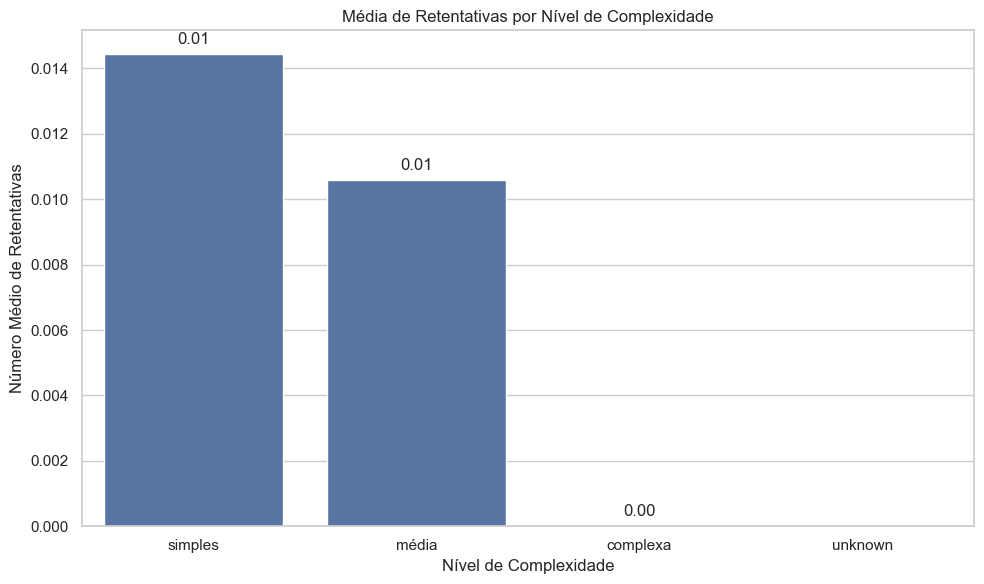

In [9]:
# 1. Distribuição de complexidade das queries
print("=== Distribuição de Complexidade das Queries ===")
complexity_counts = df_complete['query_complexity'].value_counts()
for complexity, count in complexity_counts.items():
    print(f"{complexity}: {count} queries ({count/len(df_complete)*100:.2f}%)")

# 2. Gráfico de distribuição de complexidade
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='query_complexity', data=df_complete, 
                  order=['simples', 'média', 'complexa', 'unknown'])
plt.title('Distribuição de Complexidade das Queries')
plt.xlabel('Nível de Complexidade')
plt.ylabel('Contagem')

# Adicionar valores nas barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height} ({height/len(df_complete)*100:.1f}%)', 
                (p.get_x() + p.get_width() / 2., height), 
                ha = 'center', va = 'bottom', 
                xytext = (0, 5), textcoords = 'offset points')

plt.tight_layout()
plt.show()

# 3. Taxa de sucesso por nível de complexidade
success_by_complexity = df_complete.groupby('query_complexity').agg({
    'alignment': 'mean',
    'correctness': 'mean',
    'recall': 'mean'
}) * 100

print("\n=== Taxa de Sucesso por Complexidade ===")
print(success_by_complexity)

# 4. Gráfico de taxa de sucesso por complexidade
success_by_complexity_melted = success_by_complexity.reset_index().melt(
    id_vars=['query_complexity'],
    value_vars=['alignment', 'correctness', 'recall'],
    var_name='Métrica',
    value_name='Taxa (%)'
)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x='query_complexity', y='Taxa (%)', hue='Métrica', 
                data=success_by_complexity_melted,
                order=['simples', 'média', 'complexa', 'unknown'])
plt.title('Taxa de Sucesso por Nível de Complexidade')
plt.xlabel('Nível de Complexidade')
plt.ylabel('Taxa de Sucesso (%)')
plt.ylim(0, 100)
plt.legend(title='Métrica')

plt.tight_layout()
plt.show()

# 5. Número médio de retentativas por complexidade
retries_by_complexity = df_complete.groupby('query_complexity')['retry_count'].mean()

print("\n=== Média de Retentativas por Complexidade ===")
print(retries_by_complexity)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=retries_by_complexity.index, y=retries_by_complexity.values, 
                order=['simples', 'média', 'complexa', 'unknown'])
plt.title('Média de Retentativas por Nível de Complexidade')
plt.xlabel('Nível de Complexidade')
plt.ylabel('Número Médio de Retentativas')

# Adicionar valores nas barras
for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'bottom', 
                xytext = (0, 5), textcoords = 'offset points')

plt.tight_layout()
plt.show()

## Análise Temporal e de Eficiência

=== Estatísticas de Tempo de Execução ===
Tempo médio de execução por interação: 18.65 segundos

Tempo médio de execução por complexidade:
query_complexity
complexa    21.189016
média       19.140290
simples     20.509707
Name: turn_execution_time, dtype: float64


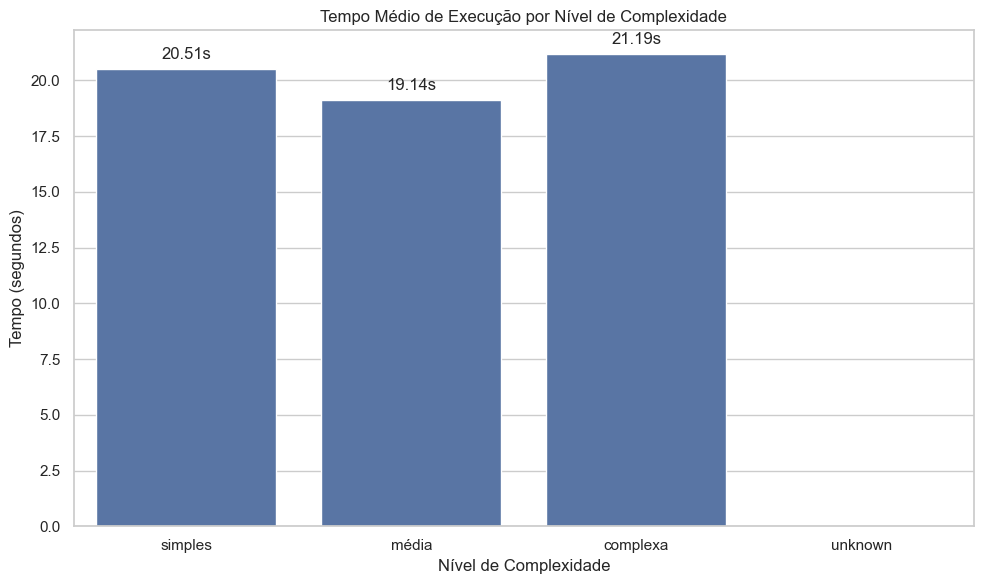

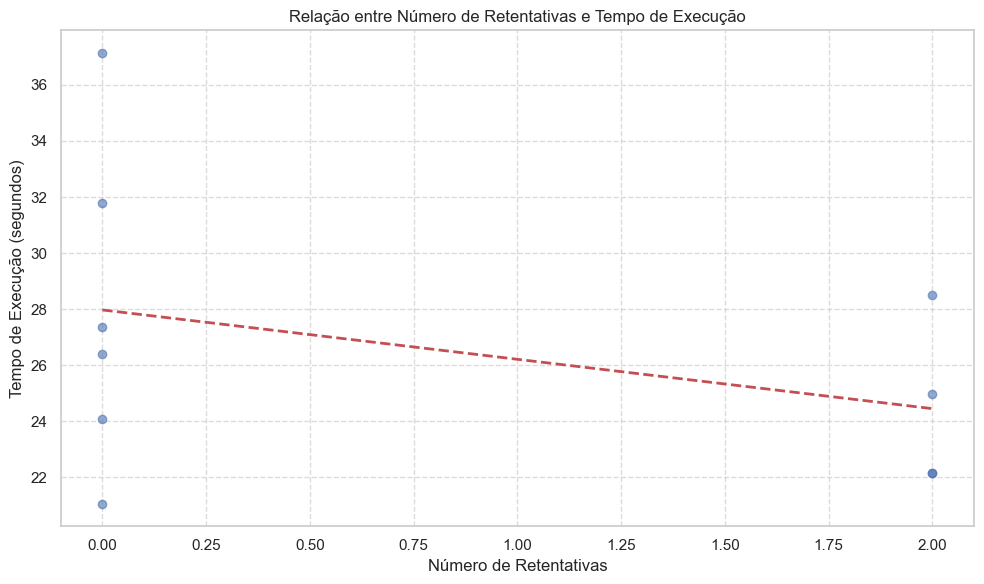

In [10]:
# 1. Tempo médio de execução por interação
print("=== Estatísticas de Tempo de Execução ===")
avg_execution_time = df[df['interaction_execution_time'] > 0]['interaction_execution_time'].mean()
print(f"Tempo médio de execução por interação: {avg_execution_time:.2f} segundos")

# 2. Tempo de execução por complexidade
time_by_complexity = df_complete.groupby('query_complexity')['turn_execution_time'].mean()
print("\nTempo médio de execução por complexidade:")
print(time_by_complexity)

# 3. Gráfico de tempo por complexidade
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=time_by_complexity.index, y=time_by_complexity.values, 
                order=['simples', 'média', 'complexa', 'unknown'])
plt.title('Tempo Médio de Execução por Nível de Complexidade')
plt.xlabel('Nível de Complexidade')
plt.ylabel('Tempo (segundos)')

# Adicionar valores nas barras
for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_height():.2f}s', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'bottom', 
                xytext = (0, 5), textcoords = 'offset points')

plt.tight_layout()
plt.show()

# 4. Relação entre tempo de execução e número de retentativas
execution_vs_retries = df.groupby('interaction_id').agg({
    'interaction_execution_time': 'max',
    'total_retries_needed': 'max'
}).reset_index()

execution_vs_retries = execution_vs_retries[execution_vs_retries['interaction_execution_time'] > 0]

plt.figure(figsize=(10, 6))
plt.scatter(execution_vs_retries['total_retries_needed'], 
           execution_vs_retries['interaction_execution_time'], 
           alpha=0.6)

plt.title('Relação entre Número de Retentativas e Tempo de Execução')
plt.xlabel('Número de Retentativas')
plt.ylabel('Tempo de Execução (segundos)')
plt.grid(True, linestyle='--', alpha=0.7)

# Adicionar linha de tendência
z = np.polyfit(execution_vs_retries['total_retries_needed'], 
              execution_vs_retries['interaction_execution_time'], 1)
p = np.poly1d(z)
plt.plot(np.unique(execution_vs_retries['total_retries_needed']), 
         p(np.unique(execution_vs_retries['total_retries_needed'])), 
         'r--', linewidth=2)

plt.tight_layout()
plt.show()

=== Estatísticas de Tempo de Execução ===

Tempo médio de execução por interação: 17.48 segundos

Tempo médio de execução por complexidade:

query_complexity

complexa    13.540571

média       15.802048

simples     15.207899

Name: turn_execution_time, dtype: float64

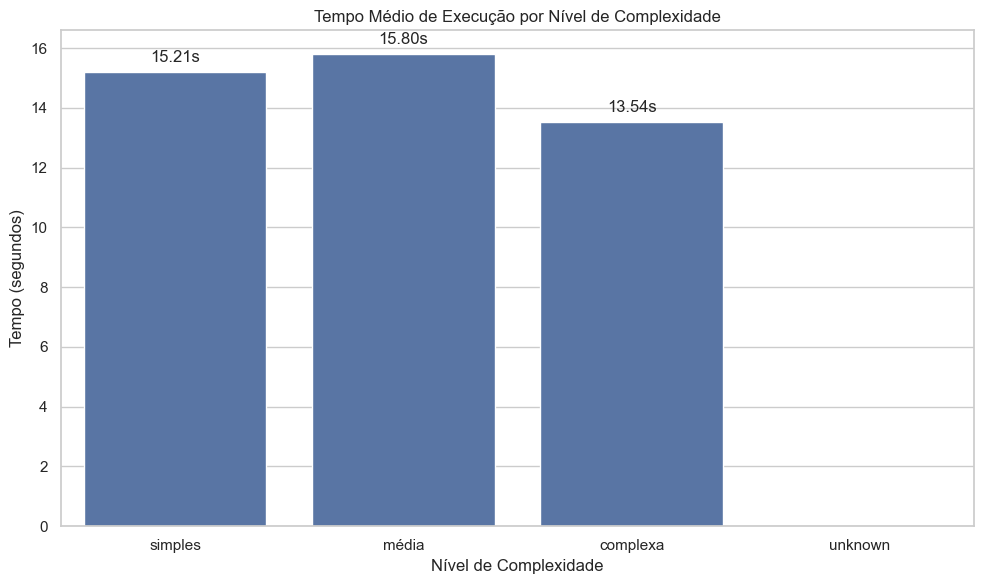

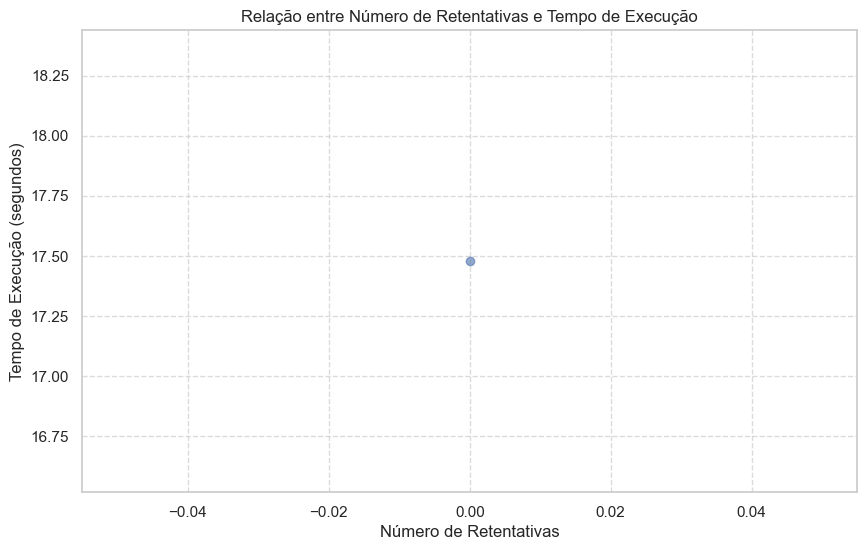

## Análise por Experimento e Comparações

=== Métricas por Experimento ===
               alignment  correctness  recall  total_retries_needed  \
experiment_id                                                         
1               0.909091     0.545455    0.00              0.363636   
10              1.000000     0.800000    0.00              0.000000   
11              1.000000     0.900000    0.00              0.000000   
12              1.000000     0.200000    0.00              0.000000   
13              0.909091     0.545455    0.00              0.363636   
14              1.000000     0.800000    0.00              0.000000   
15              1.000000     1.000000    0.00              0.000000   
16              1.000000     0.800000    0.00              0.000000   
17              1.000000     0.500000    0.00              0.000000   
18              1.000000     0.900000    0.00              0.000000   
19              1.000000     0.700000    0.00              0.000000   
2               1.000000     0.500000    0.0

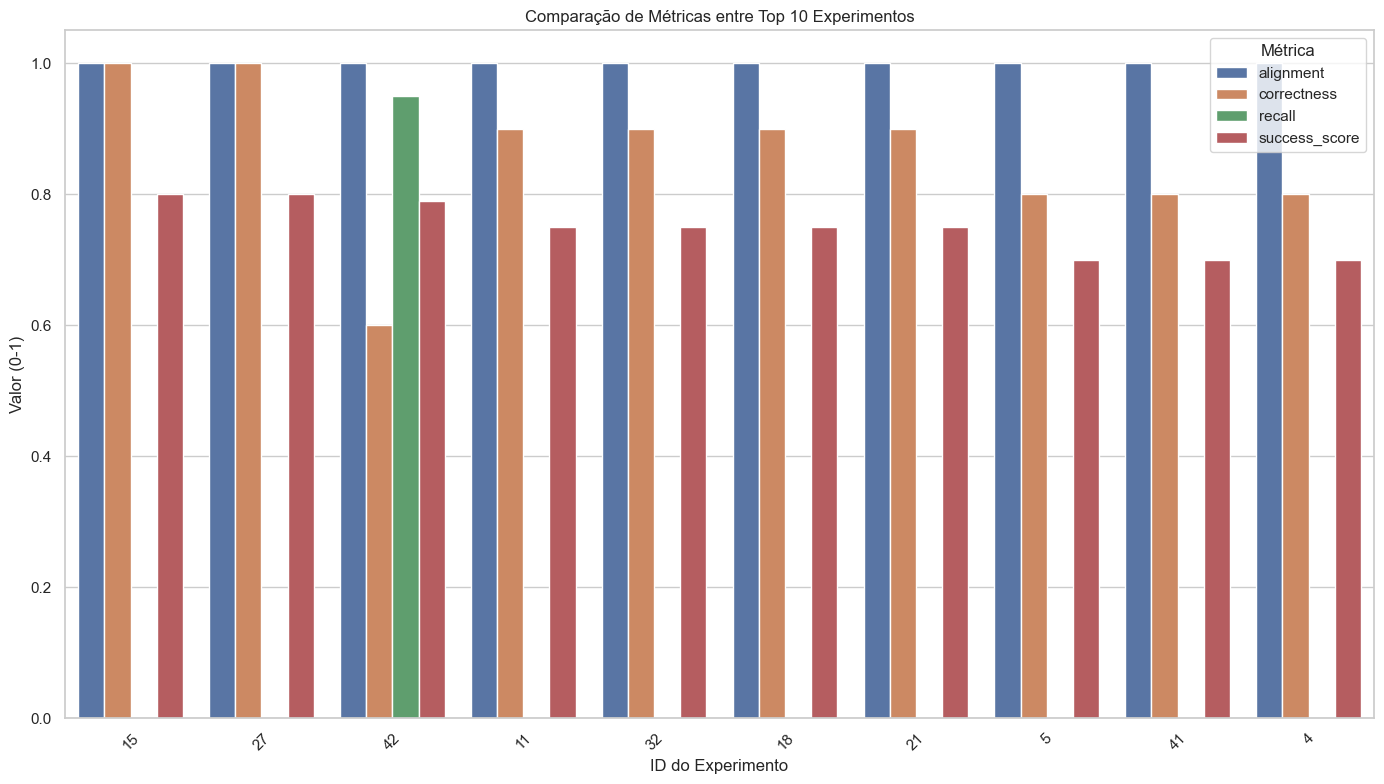


=== Comparação entre Modelos ===
               alignment  correctness    recall  total_retries_needed  \
model_version                                                           
default         0.987903     0.612903  0.019153              0.048387   

               turn_execution_time  
model_version                       
default                   20.02898  


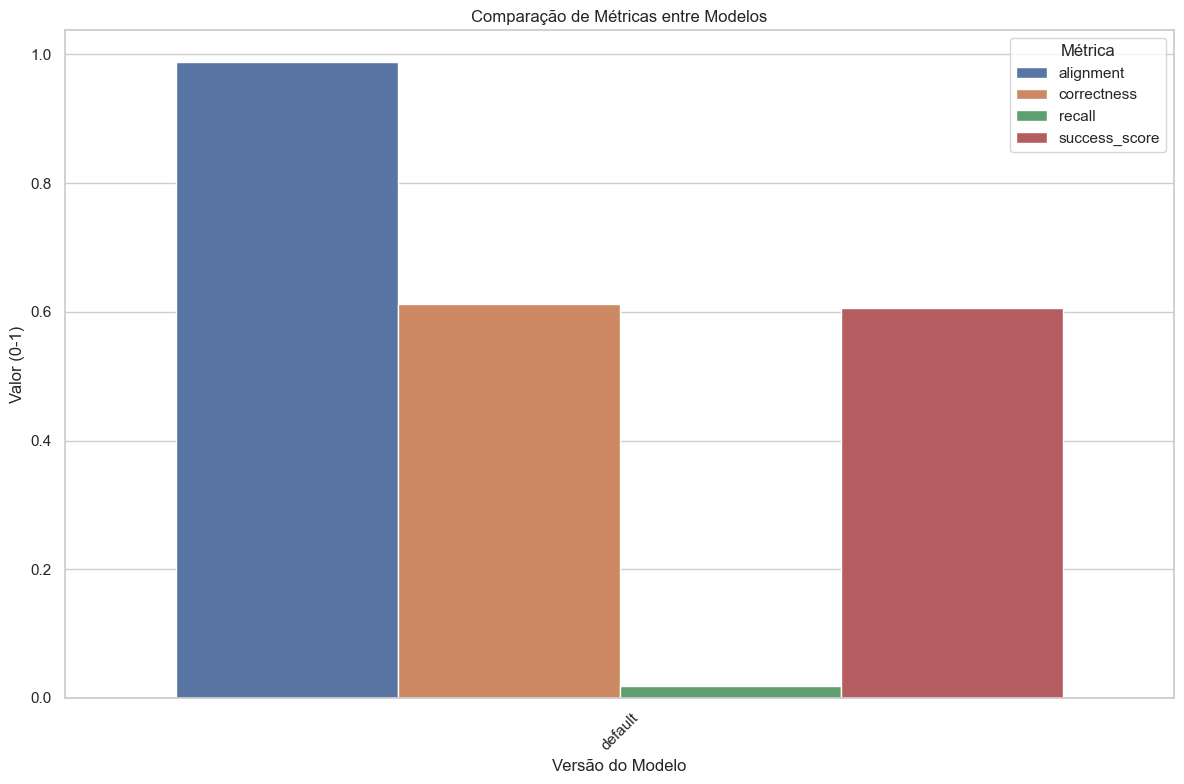

In [11]:
# 1. Métricas agregadas por experimento
metrics_by_experiment = df_complete.groupby('experiment_id').agg({
    'alignment': 'mean',
    'correctness': 'mean',
    'recall': 'mean',
    'total_retries_needed': 'mean',
    'turn_execution_time': 'mean',
    'interaction_id': 'nunique'
}).rename(columns={
    'interaction_id': 'total_interactions'
})

print("=== Métricas por Experimento ===")
print(metrics_by_experiment)

# 2. Adicionar modelo usado em cada experimento
model_by_experiment = df[['experiment_id', 'model_version']].drop_duplicates().set_index('experiment_id')
metrics_by_experiment = metrics_by_experiment.join(model_by_experiment)

# 3. Mostrar os melhores experimentos por taxa de sucesso geral
success_score = (metrics_by_experiment['alignment'] * 0.3 + 
                 metrics_by_experiment['correctness'] * 0.5 + 
                 metrics_by_experiment['recall'] * 0.2)
metrics_by_experiment['success_score'] = success_score

print("\n=== Top 5 Experimentos por Taxa de Sucesso ===")
print(metrics_by_experiment.sort_values('success_score', ascending=False).head(5))

# 4. Comparação visual entre experimentos (top 10)
top_experiments = metrics_by_experiment.sort_values('success_score', ascending=False).head(10)

metrics_melted = top_experiments.reset_index().melt(
    id_vars=['experiment_id', 'model_version'],
    value_vars=['alignment', 'correctness', 'recall', 'success_score'],
    var_name='Métrica',
    value_name='Valor'
)

plt.figure(figsize=(14, 8))
ax = sns.barplot(x='experiment_id', y='Valor', hue='Métrica', data=metrics_melted)
plt.title('Comparação de Métricas entre Top 10 Experimentos')
plt.xlabel('ID do Experimento')
plt.ylabel('Valor (0-1)')
plt.legend(title='Métrica')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 5. Comparação por modelos
metrics_by_model = df_complete.groupby('model_version').agg({
    'alignment': 'mean',
    'correctness': 'mean',
    'recall': 'mean',
    'total_retries_needed': 'mean',
    'turn_execution_time': 'mean'
})

print("\n=== Comparação entre Modelos ===")
print(metrics_by_model)

# 6. Gráfico comparativo entre modelos
metrics_by_model['success_score'] = (metrics_by_model['alignment'] * 0.3 + 
                                    metrics_by_model['correctness'] * 0.5 + 
                                    metrics_by_model['recall'] * 0.2)

model_metrics_melted = metrics_by_model.reset_index().melt(
    id_vars=['model_version'],
    value_vars=['alignment', 'correctness', 'recall', 'success_score'],
    var_name='Métrica',
    value_name='Valor'
)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x='model_version', y='Valor', hue='Métrica', data=model_metrics_melted)
plt.title('Comparação de Métricas entre Modelos')
plt.xlabel('Versão do Modelo')
plt.ylabel('Valor (0-1)')
plt.legend(title='Métrica')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Análise de Motivos Específicos de Falha

=== Análise de Falhas ===
Total de turnos com falha: 193 (38.91%)
Falhas de alinhamento (alignment): 6 (3.11%)
Falhas de correção SQL (correctness): 192 (99.48%)
Falhas em ambos: 5 (2.59%)


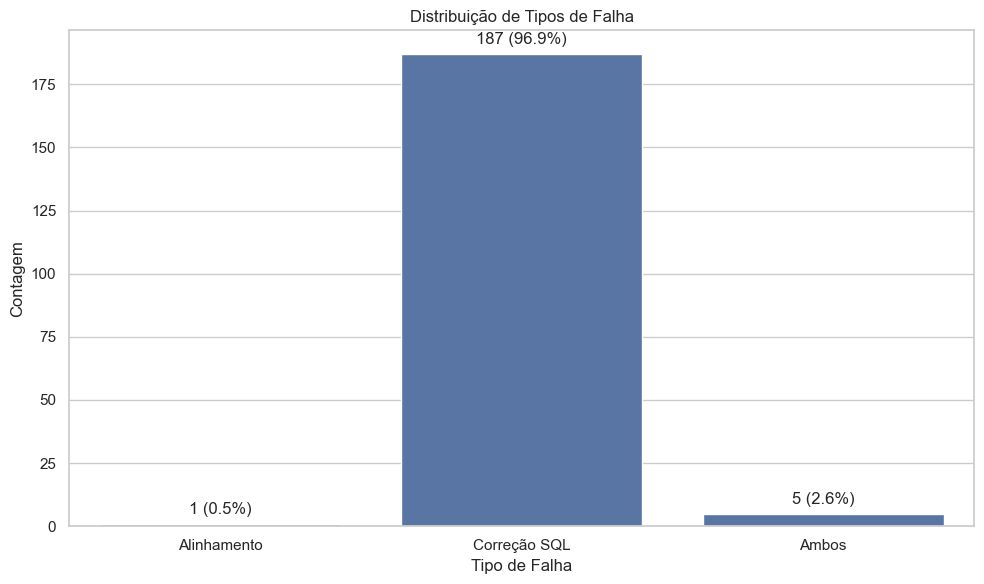


=== Taxa de Falha por Nível de Complexidade ===
complexa: 36.67% (11/30)
média: 43.39% (82/189)
simples: 36.10% (100/277)


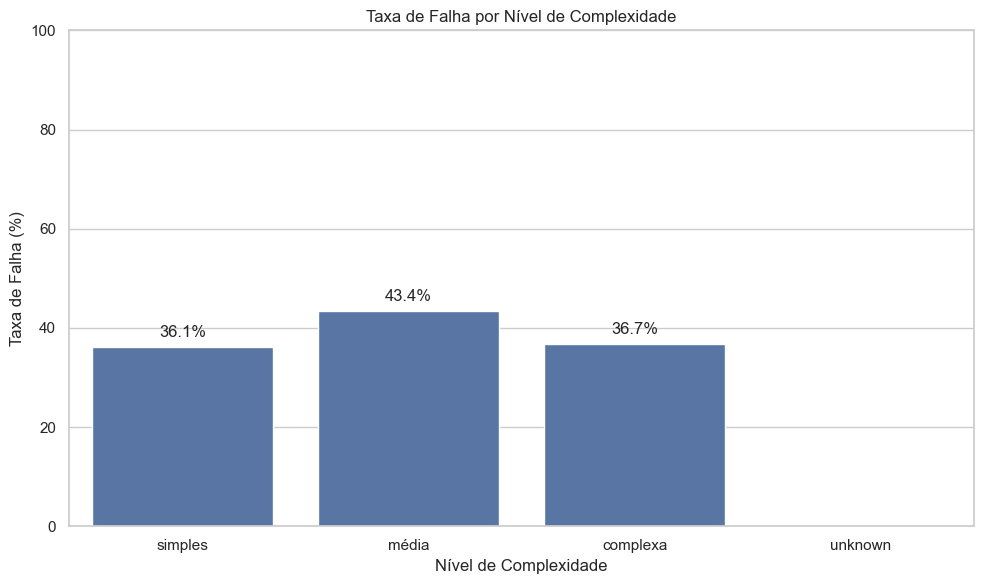

In [12]:
# 1. Identificar padrões de falha comuns
# Filtrar apenas os turnos com falhas
failed_turns = df_complete[(df_complete['alignment'] == False) | 
                           (df_complete['correctness'] == False)]

print("=== Análise de Falhas ===")
print(f"Total de turnos com falha: {len(failed_turns)} ({len(failed_turns)/len(df_complete)*100:.2f}%)")

# 2. Distribuição dos tipos de falha
alignment_fails = sum(failed_turns['alignment'] == False)
correctness_fails = sum(failed_turns['correctness'] == False)
both_fails = sum((failed_turns['alignment'] == False) & (failed_turns['correctness'] == False))

print(f"Falhas de alinhamento (alignment): {alignment_fails} ({alignment_fails/len(failed_turns)*100:.2f}%)")
print(f"Falhas de correção SQL (correctness): {correctness_fails} ({correctness_fails/len(failed_turns)*100:.2f}%)")
print(f"Falhas em ambos: {both_fails} ({both_fails/len(failed_turns)*100:.2f}%)")

# 3. Gráfico de distribuição de falhas
fail_types = pd.DataFrame({
    'Tipo de Falha': ['Alinhamento', 'Correção SQL', 'Ambos'],
    'Contagem': [alignment_fails - both_fails, correctness_fails - both_fails, both_fails]
})

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Tipo de Falha', y='Contagem', data=fail_types)
plt.title('Distribuição de Tipos de Falha')
plt.xlabel('Tipo de Falha')
plt.ylabel('Contagem')

# Adicionar valores nas barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)} ({height/len(failed_turns)*100:.1f}%)', 
                (p.get_x() + p.get_width() / 2., height), 
                ha = 'center', va = 'bottom', 
                xytext = (0, 5), textcoords = 'offset points')

plt.tight_layout()
plt.show()

# 4. Falhas por nível de complexidade
fails_by_complexity = failed_turns.groupby('query_complexity').size()
total_by_complexity = df_complete.groupby('query_complexity').size()
fail_rate_by_complexity = (fails_by_complexity / total_by_complexity * 100).fillna(0)

print("\n=== Taxa de Falha por Nível de Complexidade ===")
for complexity, rate in fail_rate_by_complexity.items():
    print(f"{complexity}: {rate:.2f}% ({fails_by_complexity.get(complexity, 0)}/{total_by_complexity.get(complexity, 0)})")

# 5. Gráfico de taxa de falha por complexidade
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=fail_rate_by_complexity.index, y=fail_rate_by_complexity.values, 
                order=['simples', 'média', 'complexa', 'unknown'])
plt.title('Taxa de Falha por Nível de Complexidade')
plt.xlabel('Nível de Complexidade')
plt.ylabel('Taxa de Falha (%)')
plt.ylim(0, 100)

# Adicionar valores nas barras
for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'bottom', 
                xytext = (0, 5), textcoords = 'offset points')

plt.tight_layout()
plt.show()

## Análise de Fluxo de Diálogo

=== Análise de Fluxo de Diálogo ===
Distribuição do número de turnos por interação:
49 turno(s): 6 interações (60.00%)
50 turno(s): 2 interações (20.00%)
51 turno(s): 2 interações (20.00%)


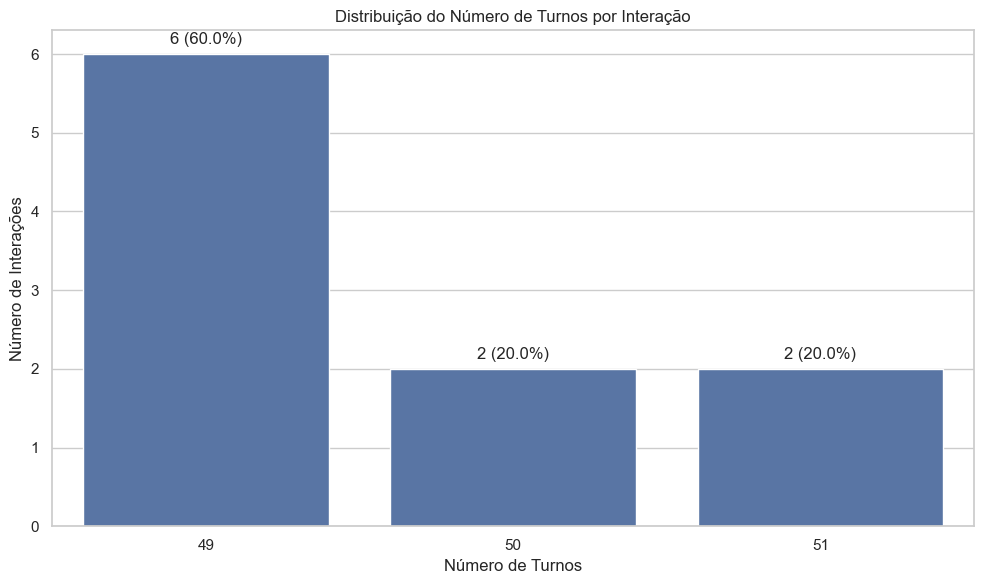


=== Taxa de Sucesso por Número de Turnos ===
49 turno(s): 66.67% de sucesso
50 turno(s): 100.00% de sucesso
51 turno(s): 0.00% de sucesso


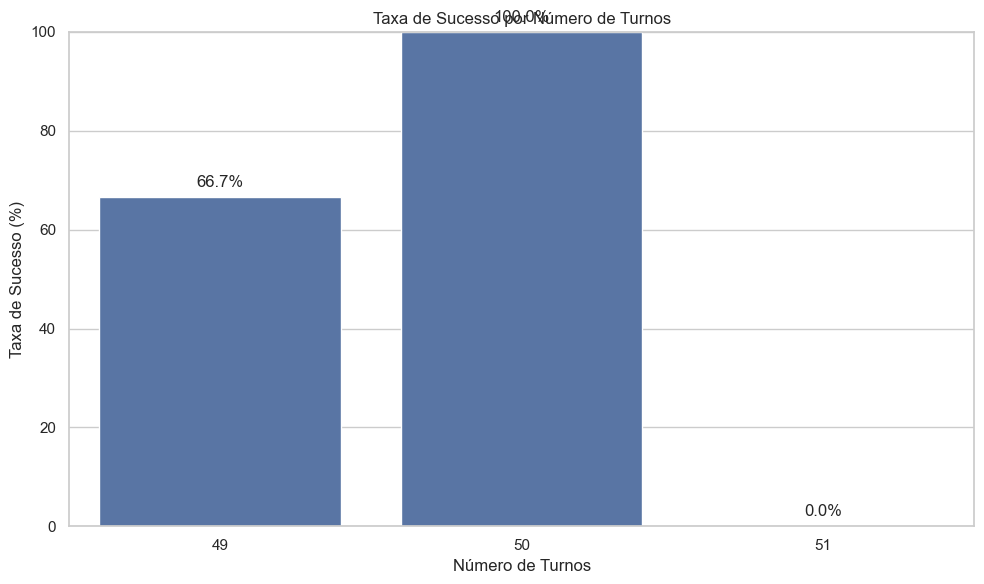


=== Correlação entre Número de Turnos e Retentativas ===
Correlação: 0.9186


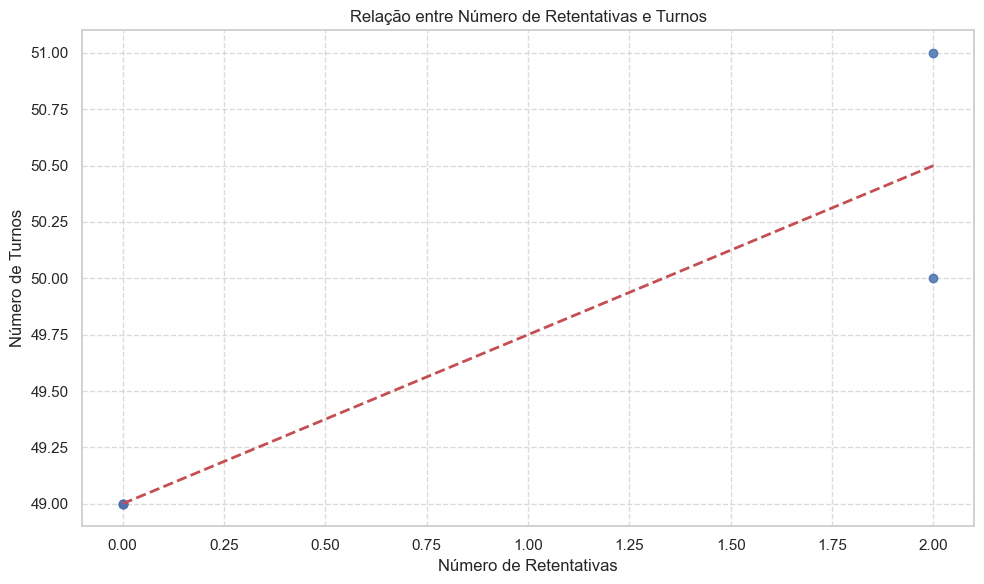

In [13]:
## 1. Análise do número de turnos por interação
turns_per_interaction = df.groupby('interaction_id').size()
turn_distribution = turns_per_interaction.value_counts().sort_index()

print("=== Análise de Fluxo de Diálogo ===")
print("Distribuição do número de turnos por interação:")
for turns, count in turn_distribution.items():
    print(f"{turns} turno(s): {count} interações ({count/len(turns_per_interaction)*100:.2f}%)")

# 2. Gráfico de distribuição de turnos por interação
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=turns_per_interaction, order=sorted(turns_per_interaction.unique()))
plt.title('Distribuição do Número de Turnos por Interação')
plt.xlabel('Número de Turnos')
plt.ylabel('Número de Interações')

# Adicionar valores nas barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)} ({height/len(turns_per_interaction)*100:.1f}%)', 
                (p.get_x() + p.get_width() / 2., height), 
                ha = 'center', va = 'bottom', 
                xytext = (0, 5), textcoords = 'offset points')

plt.tight_layout()
plt.show()

# 3. Taxa de sucesso por número de turnos
success_by_turns = df.groupby('interaction_id').agg({
    'turn_id': 'count',
    'correctness': lambda x: x.iloc[-1] if not x.empty and not x.iloc[-1] is None else None
}).rename(columns={'turn_id': 'num_turns'}).dropna()

success_by_turns_grouped = success_by_turns.groupby('num_turns')['correctness'].mean() * 100

print("\n=== Taxa de Sucesso por Número de Turnos ===")
for turns, rate in success_by_turns_grouped.items():
    print(f"{turns} turno(s): {rate:.2f}% de sucesso")

# 4. Gráfico de taxa de sucesso por número de turnos
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=success_by_turns_grouped.index, y=success_by_turns_grouped.values)
plt.title('Taxa de Sucesso por Número de Turnos')
plt.xlabel('Número de Turnos')
plt.ylabel('Taxa de Sucesso (%)')
plt.ylim(0, 100)

# Adicionar valores nas barras
for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'bottom', 
                xytext = (0, 5), textcoords = 'offset points')

plt.tight_layout()
plt.show()

# 5. Relação entre número de turnos e retentativas
turn_vs_retry = df.groupby('interaction_id').agg({
    'turn_id': 'count',
    'total_retries_needed': 'max'
}).rename(columns={'turn_id': 'num_turns'})

print("\n=== Correlação entre Número de Turnos e Retentativas ===")
correlation = turn_vs_retry['num_turns'].corr(turn_vs_retry['total_retries_needed'])
print(f"Correlação: {correlation:.4f}")

# 6. Gráfico de dispersão (scatter plot)
plt.figure(figsize=(10, 6))
plt.scatter(turn_vs_retry['total_retries_needed'], turn_vs_retry['num_turns'], alpha=0.6)
plt.title('Relação entre Número de Retentativas e Turnos')
plt.xlabel('Número de Retentativas')
plt.ylabel('Número de Turnos')
plt.grid(True, linestyle='--', alpha=0.7)

# Adicionar linha de tendência
z = np.polyfit(turn_vs_retry['total_retries_needed'], turn_vs_retry['num_turns'], 1)
p = np.poly1d(z)
plt.plot(np.unique(turn_vs_retry['total_retries_needed']), 
         p(np.unique(turn_vs_retry['total_retries_needed'])), 
         'r--', linewidth=2)

plt.tight_layout()
plt.show()

## Índice Global de Qualidade e Recomendações

=== Índice Global de Qualidade ===
               quality_score
experiment_id               
42                 85.250000
27                 85.000000
15                 85.000000
18                 81.500000
21                 81.500000
32                 81.500000
11                 81.500000
22                 78.000000
10                 78.000000
34                 78.000000
49                 78.000000
5                  78.000000
26                 78.000000
4                  78.000000
14                 78.000000
41                 78.000000
44                 78.000000
16                 78.000000
37                 74.500000
20                 74.500000
46                 74.500000
28                 74.500000
19                 74.500000
43                 71.000000
47                 71.000000
40                 71.000000
45                 71.000000
25                 71.000000
50                 71.000000
7                  71.000000
39                 67.500000
2       

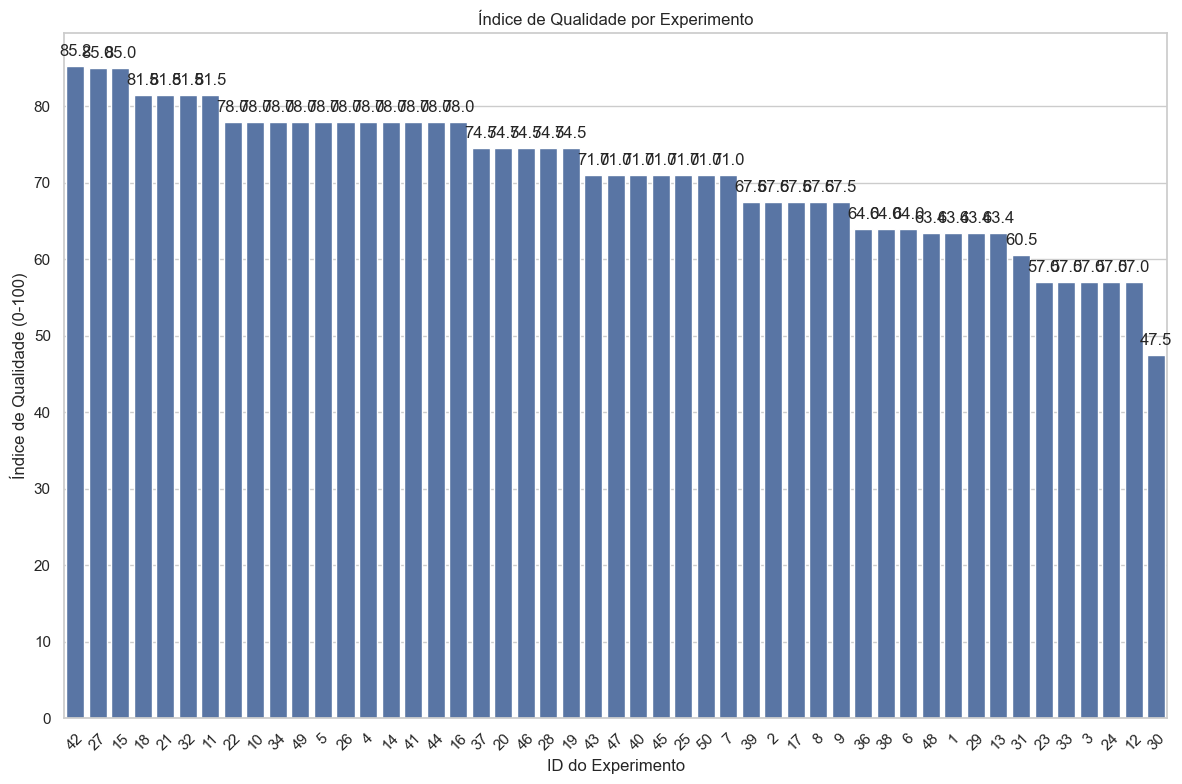


=== Recomendações Baseadas na Análise ===
Principais motivos de retentativa:
- alignment_and_correctness_failure: 4 ocorrências
- alignment_failure: 1 ocorrências
- feedback_needed: 1 ocorrências

Nível de complexidade com maior taxa de falha: média (43.4%)

Melhor modelo baseado no score composto: default (Score: 60.7%)

Sugestões de melhoria:


In [14]:
# 1. Calcular índices compostos de qualidade
print("=== Índice Global de Qualidade ===")

# Definir pesos para os componentes
weights = {
    'alignment': 0.25,           # Importância do alinhamento com intenção do usuário
    'correctness': 0.35,         # Importância da correção SQL
    'recall': 0.15,              # Importância da identificação correta de tabelas
    'retry_penalty': 0.15,       # Penalização por retentativas
    'turn_penalty': 0.10         # Penalização por turnos extras
}

# Calcular métricas por experimento para o índice
quality_metrics = df_complete.groupby('experiment_id').agg({
    'alignment': 'mean',
    'correctness': 'mean',
    'recall': 'mean'
})

# Adicionar métricas de interação
interaction_metrics = df.groupby(['experiment_id', 'interaction_id']).agg({
    'total_retries_needed': 'max',
    'turn_id': 'count'
}).groupby('experiment_id').mean()

interaction_metrics.columns = ['avg_retries', 'avg_turns']

# Combinar métricas
quality_metrics = quality_metrics.join(interaction_metrics)

# Calcular eficiência (inversamente proporcional a retries e turnos)
quality_metrics['retry_efficiency'] = 1 / (1 + quality_metrics['avg_retries'])
quality_metrics['turn_efficiency'] = 1 / quality_metrics['avg_turns']

# Calcular o índice composto
quality_metrics['quality_index'] = (
    weights['alignment'] * quality_metrics['alignment'] +
    weights['correctness'] * quality_metrics['correctness'] +
    weights['recall'] * quality_metrics['recall'] +
    weights['retry_penalty'] * quality_metrics['retry_efficiency'] +
    weights['turn_penalty'] * quality_metrics['turn_efficiency']
)

# Normalizar para escala 0-100
max_possible_index = sum(weights.values())
quality_metrics['quality_score'] = (quality_metrics['quality_index'] / max_possible_index) * 100

print(quality_metrics[['quality_score']].sort_values('quality_score', ascending=False))

# 2. Gráfico do índice de qualidade por experimento
top_quality = quality_metrics.sort_values('quality_score', ascending=False)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x=top_quality.index, y=top_quality['quality_score'])
plt.title('Índice de Qualidade por Experimento')
plt.xlabel('ID do Experimento')
plt.ylabel('Índice de Qualidade (0-100)')
plt.xticks(rotation=45)

# Adicionar valores nas barras
for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'bottom', 
                xytext = (0, 5), textcoords = 'offset points')

plt.tight_layout()
plt.show()

# 3. Recomendações baseadas na análise
print("\n=== Recomendações Baseadas na Análise ===")

# Problemas mais comuns
common_retry_reasons = retry_turns['retry_reason'].value_counts().head(3)
print("Principais motivos de retentativa:")
for reason, count in common_retry_reasons.items():
    print(f"- {reason}: {count} ocorrências")

# Problemas por complexidade
worst_complexity = fail_rate_by_complexity.idxmax()
print(f"\nNível de complexidade com maior taxa de falha: {worst_complexity} ({fail_rate_by_complexity.max():.1f}%)")

# Melhor modelo
best_model = metrics_by_model['success_score'].idxmax()
print(f"\nMelhor modelo baseado no score composto: {best_model} (Score: {metrics_by_model.loc[best_model, 'success_score']*100:.1f}%)")

# Sugestões gerais
print("\nSugestões de melhoria:")
if common_retry_reasons.index[0] == 'alignment_failure':
    print("- Melhorar o entendimento da intenção do usuário, possivelmente reformulando as prompts")
elif common_retry_reasons.index[0] == 'correctness_failure':
    print("- Focar na geração de SQL correta, possivelmente usando mais exemplos ou validação")
elif common_retry_reasons.index[0] == 'json_decode_error':
    print("- Melhorar o formato de resposta para garantir JSON válido")

if worst_complexity == 'complexa':
    print("- Adicionar mais exemplos de queries complexas ao treinamento")
    print("- Considerar decompor queries complexas em etapas intermediárias")